# EDA – MNIST Handskrivna Siffror

**Syfte:** Utforska MNIST-datasetet och jämföra tre klassificeringsmodeller — LogisticRegression, RandomForestClassifier och ExtraTreesClassifier — med optimerade hyperparametrar via GridSearchCV.

**Flöde:**
1. Ladda och visualisera rådata
2. Dela upp i tränings- och testset
3. Normalisera med StandardScaler
4. Hitta bästa hyperparametrar med GridSearchCV
5. Återträna vinnande modell på full träningsdata
6. Utvärdera på testset med accuracy och confusion matrix

### Steg 1 – Läs in data och förbered

`fetch_openml` laddar MNIST med 70 000 bilder (28×28 pixlar = 784 features per bild).

Datasetet delas upp i **träning** och **test** med `stratify=y` för att säkerställa jämn fördelning av siffror i båda seten. y är datasetets y.

Därefter normaliseras data med `StandardScaler` — viktigt att den **bara fittas på träningsdata** så att information från testdatan inte läcker in i normaliseringen vid beräkningar av medelvärden mm är med.



Laddar MNIST...


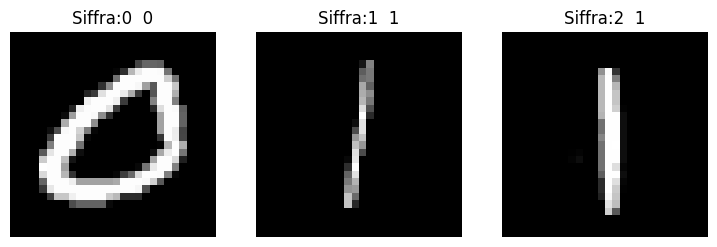

Full träning:       45000 bilder
Validering:         15000 bilder
Test:               10000 bilder
GridSearch-träning: 5000 bilder

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain gre

In [ ]:
# Vi importerar alla nödvändiga bibliotek
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import time
#import warnings warnings.filterwarnings("ignore")
import seaborn as sns

# ── 1. Ladda rådata (ingen normalisering ännu) ────────────────────────────────
print("Laddar MNIST...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False, parser='auto')

X = mnist.data          # råa pixelvärden 0-255
y = mnist.target.astype(int)

# ── 2. Dela upp i träning / validering / test ─────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=10_000, random_state=42, stratify=y
)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)


# ── 3. Rita ut några siffror (råa pixlar ger bäst bild) ───────────────────────
plt.figure(figsize=(9, 3))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_train_full[i].reshape(28, 28), cmap='gray')
    plt.title(f"Siffra:{i}  {y_train_full[i]}")
    plt.axis('off')
plt.show()

# ── 4. Normalisera med StandardScaler (fit bara på träningsdata!) ─────────────
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)   # fit + transform
X_val        = scaler.transform(X_val)              # bara transform
X_test       = scaler.transform(X_test)             # bara transform

# ── 5. Urval inför GridSearchCV så sparar vi hela träningsetet tills utvärderingen är klar─────────────────────────────────────────────
X_grid_sc = X_train_full[:5000]
y_grid_sc = y_train_full[:5000]

print(f"Full träning:       {X_train_full.shape[0]} bilder")
print(f"Validering:         {X_val.shape[0]} bilder")
print(f"Test:               {X_test.shape[0]} bilder")
print(f"GridSearch-träning: {X_grid_sc.shape[0]} bilder\n")

print(mnist.DESCR)

> **Notering från DESCR:** Bilderna i MNIST är redan centrerade med masscentrum-metoden. Vid egna prediktioner (t.ex. ritade siffror) behöver man centrera bilden manuellt för bästa resultat. Den ritatde bilden skall också läggas som en 20\*20 bild mitt i en svart 28\*28 bild. Hanterar man inte det funkar det dåligt.

### Steg 2 – Distribution av klasser

Kontrollerar att datasetet är **balanserat** — alltså att alla siffror (0–9) förekommer ungefär lika ofta. Ett obalanserat dataset kan lura modellen att bli bra på vanliga klasser men dålig på ovanliga.

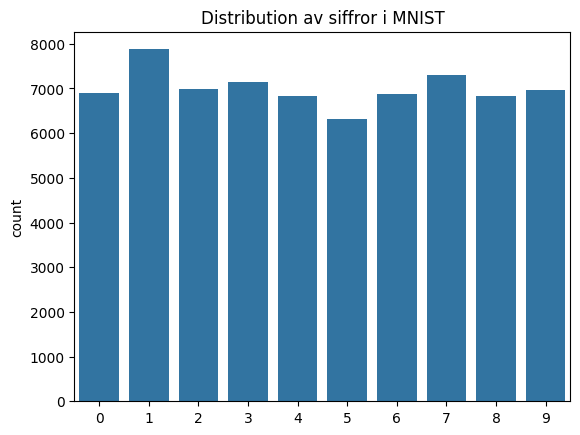

In [19]:
sns.countplot(x=mnist.target.astype(int))
plt.title("Distribution av siffror i MNIST")
plt.show()

### Steg 3 – Statistik om pixelvärdena

Min, max och medelvärde på träningsdatan efter normalisering. Medelvärdet är lågt eftersom de flesta pixlar är svarta (bakgrund) — inte så konstigt. Inga null värden i X-datan heller.

In [20]:
print(f"Min-värde:  {X_train_full.min()}")
print(f"Max-värde:  {X_train_full.max()}")
print(f"Medelvärde: {X_train_full.mean():.2f}")
print(f"Antal NaN:  {np.isnan(X_train_full).sum()}")

Min-värde:  -1.2830277465255435
Max-värde:  212.12967732061915
Medelvärde: -0.00
Antal NaN:  0


### Steg 4 – GridSearchCV: hitta bästa hyperparametrar

Definierar **parameternät** för tre modeller och en gemensam hjälpfunktion `run_grid_search`.

`GridSearchCV` med `cv=5` testar alla kombinationer av parametrar via 5-faldig korsvalidering på ett **subsampel** (`X_grid_sc`, 5 000 bilder) av träningsdatan — annars tar det för lång tid med den dator jag har. Kombinationerna sker av antal värden per hyperparameter.


| Modell | Antal kombinationer |
|--------|-------------------|
| LogisticRegression | 4 × 2 = 8 |
| RandomForestClassifier | 2 × 3 × 2 = 12 |
| ExtraTreesClassifier | 2 × 3 × 2 = 12 |

In [26]:
# --- LogisticRegression ---
param_grid_lr = {
    "C":   [0.01, 0.1, 1.0, 10.0],
    "tol": [0.01, 0.1],
}

# --- RandomForestClassifier ---
param_grid_rf = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 20, 40],
    "min_samples_split": [2, 5],
}

# --- ExtraTreesClassifier ---
param_grid_et = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 20, 40],
    "min_samples_split": [2, 5],
}

def run_grid_search(name, estimator, param_grid, X_gs, y_gs):
    print(f"\n{'='*55}")
    print(f"  GridSearchCV: {name}")
    print(f"{'='*55}")
    t0 = time.time()
    gs = GridSearchCV(
        estimator, param_grid,
        cv=5, scoring="accuracy",
        n_jobs=-1, 
        verbose=1, # Ger utskrift för varje steg i grid search
        refit=True
    )
    gs.fit(X_gs, y_gs)
    elapsed = time.time() - t0
    print(f"  Bästa params:  {gs.best_params_}")
    print(f"  CV-accuracy:   {gs.best_score_:.4f}")
    print(f"  Tid:           {elapsed:.1f}s")
    return gs

### Steg 5 – Kör GridSearch för alla tre modeller

`run_grid_search` anropas för varje modell. Resultatet — bästa parametrar och CV-accuracy — skrivs ut för varje. Jag testade att bygga med en Pipeline och köra allt i den, men det blev för tungt för min dator.

In [27]:
# LogisticRegression
grid_sc_lr = run_grid_search("LogisticRegression",
    LogisticRegression(max_iter=1000, solver="saga"), param_grid_lr, X_grid_sc, y_grid_sc)

# RandomForest
grid_sc_rf = run_grid_search("RandomForestClassifier",
    RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, X_grid_sc, y_grid_sc)

# ExtraTrees
grid_sc_et = run_grid_search("ExtraTreesClassifier",
    ExtraTreesClassifier(random_state=42, n_jobs=-1), param_grid_et, X_grid_sc, y_grid_sc)


  GridSearchCV: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Bästa params:  {'C': 10.0, 'tol': 0.01}
  CV-accuracy:   0.8770
  Tid:           15.3s

  GridSearchCV: RandomForestClassifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Bästa params:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  CV-accuracy:   0.9356
  Tid:           10.6s

  GridSearchCV: ExtraTreesClassifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Bästa params:  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
  CV-accuracy:   0.9442
  Tid:           13.4s


### Steg 6 – Återträna på full träningsdata och utvärdera

GridSearch kördes på ett subsampel (5 000 bilder). Nu återtränas varje modells bästa variant på **hela träningsdatan** (~45 000 bilder) för maximal prestanda, och utvärderas på det separata **testsetet** (10 000 bilder) som inte rörts tidigare.

In [28]:
# ── 4. Återträna bästa modell på full träningsdata, utvärdera på test ─────────

def evaluate_best(name, gs, X_train, y_train, X_test, y_test):
    print(f"\nÅtertränar {name} med bästa params på full träningsdata...")
    t0 = time.time()
    best = gs.best_estimator_
    best.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = best.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"  Test accuracy: {acc:.4f}  (träntid: {train_time:.1f}s)")
    

evaluate_best("LogisticRegression", grid_sc_lr,
    X_train_full, y_train_full, X_test, y_test)

evaluate_best("RandomForestClassifier", grid_sc_rf,
    X_train_full, y_train_full, X_test, y_test)

evaluate_best("ExtraTreesClassifier", grid_sc_et,
    X_train_full, y_train_full, X_test, y_test)



Återtränar LogisticRegression med bästa params på full träningsdata...
  Test accuracy: 0.9089  (träntid: 26.0s)

Återtränar RandomForestClassifier med bästa params på full träningsdata...
  Test accuracy: 0.9661  (träntid: 5.2s)

Återtränar ExtraTreesClassifier med bästa params på full träningsdata...
  Test accuracy: 0.9700  (träntid: 7.6s)


### Steg 7 – Vinnare: ExtraTreesClassifier

ExtraTreesClassifier presterar bäst (~97%) och är dessutom snabb att träna. Confusion matrix visar vilka siffror modellen blandar ihop. Diagonalen är korrekta prediktioner — ju mörkare diagonalen är och ljusare resten, desto bättre modell.

Vanliga förväxlingar i MNIST är t.ex. 4↔9, 3↔8 och 7↔1.

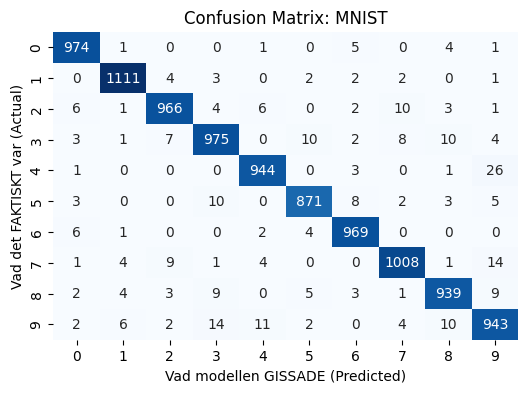

In [31]:
# Låt modellen gissa på hela testsetet
y_pred = grid_sc_et.predict(X_test)

# Skapa själva matrisen
cm = confusion_matrix(y_test, y_pred)

# Rita upp den snyggt med Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Vad modellen GISSADE (Predicted)')
plt.ylabel('Vad det FAKTISKT var (Actual)')
plt.title('Confusion Matrix: MNIST')
plt.show()

### Steg 8 – Vidare mot StreamLit
 Med EDA:n ovan känns det som om vi fått en bra känsla för MNIST datasetet och tar med oss detta resultat till appen vi byggt i Streamlit.

### Pipeline-version — StandardScaler inuti GridSearch

Här körs allt i en Pipeline per modell. Även om den koden är mer slimmad så tycker jag att läsbarheten ovan är bättre.

In [ ]:
from sklearn.pipeline import Pipeline

# Återskapa rådata-splitten (samma random_state som cell 1 → identiska index)
_X_tv, X_raw_test,  _y_tv, _ = train_test_split(X, y, test_size=10_000, random_state=42, stratify=y)
X_raw_train_full, _, _, _    = train_test_split(_X_tv, _y_tv, test_size=0.25, random_state=42, stratify=_y_tv)
X_raw_gs = X_raw_train_full[:5000]
y_raw_gs = y_train_full[:5000]

# Parameternät med prefix "clf__" för modellens parametrar
pipe_param_lr = {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__tol": [0.01, 0.1]}
pipe_param_rf = {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 20, 40], "clf__min_samples_split": [2, 5]}
pipe_param_et = {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 20, 40], "clf__min_samples_split": [2, 5]}

def run_pipeline_search(name, model, param_grid):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    model)
    ])
    print(f"\n{'='*55}\n  Pipeline GridSearchCV: {name}\n{'='*55}")
    t0 = time.time()
    gs = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, refit=True)
    gs.fit(X_raw_gs, y_raw_gs)
    print(f"  Bästa params:  {gs.best_params_}")
    print(f"  CV-accuracy:   {gs.best_score_:.4f}  ({time.time()-t0:.1f}s)")
    gs.best_estimator_.fit(X_raw_train_full, y_train_full)
    acc = accuracy_score(y_test, gs.best_estimator_.predict(X_raw_test))
    print(f"  Test accuracy: {acc:.4f}")

run_pipeline_search("LogisticRegression",     LogisticRegression(max_iter=1000, solver="saga"), pipe_param_lr)
run_pipeline_search("RandomForestClassifier", RandomForestClassifier(random_state=42, n_jobs=-1), pipe_param_rf)
run_pipeline_search("ExtraTreesClassifier",   ExtraTreesClassifier(random_state=42, n_jobs=-1),  pipe_param_et)